--- Relatório de Performance ---
Amostra (n): 69
Média Amostral (Estimador Pontual): 167.61 ms
Intervalo de Confiança (95.0%): 162.63 ms até 172.58 ms
Margem de Erro: 4.98 ms


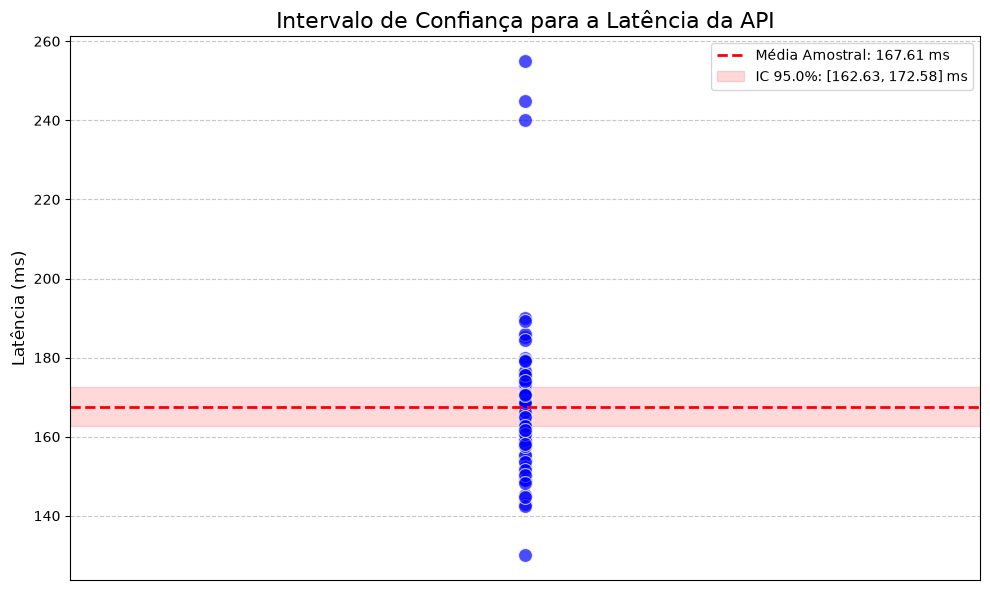

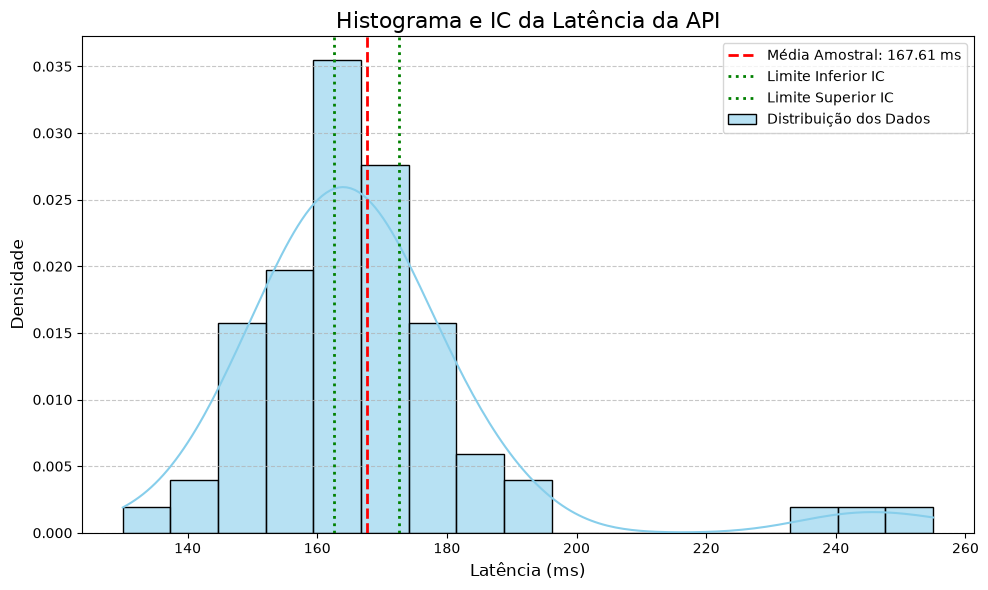

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- CÓDIGO DO CÁLCULO DO INTERVALO DE CONFIANÇA ---

# 1. Dados da Amostra (Tempos de resposta de uma API em ms)
dados= np.array([150.0,175.0,160.0,190.0,155.0,170.0,165.0,180.0, 158.0, 162.0,
    172.6,164.8,174.5,185.2,163.6,163.6,185.9,175.9,160.7,173.2,160.8,160.8,
    169.5,143.0,145.3,159.6,154.0,170.4,155.3,149.1,184.5,163.7,167.3,149.0,
    159.8,167.9,152.3,171.1,159.1,162.9,159.1,189.3,166.3,153.5,176.6,151.5,
    169.1,142.4,150.2,168.9,175.6,168.6,165.1,162.8,148.3,157.6,160.8,179.5,
    170.7,144.8,170.5,161.8,158.2,174.0,179.2,245.0,255.0,130.0,240.0,])

# 2. Parâmetros Básicos
n = len(dados)                   # Tamanho da amostra
media = np.mean(dados)           # Estimador Pontual (Média)
std_err = stats.sem(dados)       # Erro Padrão da Média (s / sqrt(n))

# 3. Definição da Confiança (95%)
confianca = 0.95

# 4. Cálculo do Intervalo de Confiança
# Usamos a distribuição t porque a amostra é pequena e o desvio padrão populacional é desconhecido
intervalo = stats.t.interval(confianca, df=n-1, loc=media, scale=std_err)
limite_inferior = intervalo[0]
limite_superior = intervalo[1]
margem_erro = limite_superior - media

# 5. Exibição dos Resultados
print(f"--- Relatório de Performance ---")
print(f"Amostra (n): {n}")
print(f"Média Amostral (Estimador Pontual): {media:.2f} ms")
print(f"Intervalo de Confiança ({confianca*100}%): {limite_inferior:.2f} ms até {limite_superior:.2f} ms")
print(f"Margem de Erro: {margem_erro:.2f} ms")

# --- CÓDIGO PARA GERAÇÃO DO GRÁFICO ---

plt.figure(figsize=(10, 6)) # Define o tamanho da figura

# 1. Scatter Plot dos Dados Individuais
# Criamos um eixo Y para os dados e um eixo X constante para a visualização
sns.scatterplot(x=np.zeros_like(dados), y=dados, s=100, color='blue', alpha=0.7, zorder=2)

# 2. Linha da Média Amostral
plt.axhline(media, color='red', linestyle='--', linewidth=2, label=f'Média Amostral: {media:.2f} ms')

# 3. Intervalo de Confiança
# Usamos fill_between para preencher a área do IC
plt.axhspan(limite_inferior, limite_superior, color='red', alpha=0.15, label=f'IC {confianca*100}%: [{limite_inferior:.2f}, {limite_superior:.2f}] ms')

# 4. Ajustes Visuais do Gráfico
plt.title('Intervalo de Confiança para a Latência da API', fontsize=16)
plt.ylabel('Latência (ms)', fontsize=12)
plt.xticks([]) # Remove os ticks do eixo X, já que ele é apenas um placeholder para o scatterplot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout() # Ajusta o layout para evitar cortes
plt.show()

# --- CÓDIGO ADICIONAL: Visualização da Distribuição (Opcional, mas útil) ---
# Se quiser ver a forma da distribuição dos dados com o IC
plt.figure(figsize=(10, 6))
sns.histplot(dados, kde=True, color='skyblue', stat='density', alpha=0.6, label='Distribuição dos Dados')
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média Amostral: {media:.2f} ms')
plt.axvline(limite_inferior, color='green', linestyle=':', linewidth=2, label='Limite Inferior IC')
plt.axvline(limite_superior, color='green', linestyle=':', linewidth=2, label='Limite Superior IC')
plt.title('Histograma e IC da Latência da API', fontsize=16)
plt.xlabel('Latência (ms)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()